# GRPO Curriculum: 8x8 → 10x10 → 12x12 → 16x16

GRPO с curriculum learning поверх SFT checkpoint из `gleror/sft-curriculum-final`.

- **Init:** веса из SFT curriculum (8→10→12→16)
- **Train:** поэтапно 8x8 → 10x10 → 12x12 → 16x16 (веса переносятся между стадиями)
- **Eval:** 16x16 после каждой стадии + финальное сравнение с SFT

In [1]:
!pip install -q gymnasium minigrid torch torchvision pillow tqdm matplotlib transformers huggingface-hub safetensors
!test -d nanoVLM || git clone --branch v0.1 --depth 1 https://github.com/huggingface/nanoVLM.git

import sys
sys.path.insert(0, "nanoVLM")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 3.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 55.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.4 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 

In [4]:
import json
import random
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import minigrid
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from minigrid.envs.empty import EmptyEnv
from torch.distributions import Categorical
from tqdm.auto import tqdm

from data.processors import get_image_processor, get_tokenizer
from models.config import VLMConfig
from models.vision_language_model import VisionLanguageModel

for size in [10, 12, 14]:
    env_id = f"MiniGrid-Empty-{size}x{size}-v0"
    if env_id not in gym.envs.registry:
        gym.register(id=env_id, entry_point=EmptyEnv, kwargs={"size": size})

SFT_DATASET_CANDIDATES = [
    Path("/kaggle/input/datasets/gleror/sft-curriculum-final"),
    Path("output"),
]
SFT_DATASET_PATH = next((p for p in SFT_DATASET_CANDIDATES if (p / "checkpoint").exists()), None)

SFT_CHECKPOINT = SFT_DATASET_PATH / "checkpoint"
OUTPUT_DIR = Path("/kaggle/working/grpo_curriculum" if Path("/kaggle").exists() else "grpo_curriculum_output")

STAGES = [
    {"env": "MiniGrid-Empty-8x8-v0",   "iters": 10, "max_steps": 50},
    {"env": "MiniGrid-Empty-10x10-v0", "iters": 20, "max_steps": 70},
    {"env": "MiniGrid-Empty-12x12-v0", "iters": 30, "max_steps": 90},
    {"env": "MiniGrid-Empty-16x16-v0", "iters": 40, "max_steps": 150},
]
N_ITERATIONS = sum(s["iters"] for s in STAGES)

EVAL_ENV = "MiniGrid-Empty-16x16-v0"
EVAL_ENVS = ["MiniGrid-Empty-8x8-v0", "MiniGrid-Empty-16x16-v0"]
PROMPT = (
    "Question: You are a navigation agent in a grid world. "
    "Choose the next action: 0=left, 1=right, 2=forward. Answer:"
)

K_GROUP = 8
EVAL_MAX_STEPS = 150
LR = 1e-5
BETA_KL = 0.01
STEP_PENALTY = 0.01
DISTANCE_REWARD_SCALE = 0.5
PER_STEP_PROGRESS_SCALE = 0.1
TEMPERATURE = 1.5
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = get_tokenizer(VLMConfig.lm_tokenizer)
image_processor = get_image_processor(VLMConfig.vit_img_size)
ACTION_TOKEN_IDS = [tokenizer.encode(str(a), add_special_tokens=False)[0] for a in range(3)]

print(f"Device: {device}")
print(f"SFT checkpoint: {SFT_CHECKPOINT}")
print(f"Curriculum: {N_ITERATIONS} total iters across {len(STAGES)} stages")
for i, s in enumerate(STAGES):
    label = s["env"].replace("MiniGrid-Empty-", "").replace("-v0", "")
    print(f"  Stage {i + 1}: {label} — {s['iters']} iters, max_steps={s['max_steps']}")
print(f"Action token IDs: {ACTION_TOKEN_IDS}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/489 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device: cuda
SFT checkpoint: /kaggle/input/datasets/gleror/sft-curriculum-final/checkpoint
Curriculum: 100 total iters across 4 stages
  Stage 1: 8x8 — 10 iters, max_steps=50
  Stage 2: 10x10 — 20 iters, max_steps=70
  Stage 3: 12x12 — 30 iters, max_steps=90
  Stage 4: 16x16 — 40 iters, max_steps=150
Action token IDs: [32, 33, 34]


## 2. Load SFT checkpoint

`model` — обучаемая политика. `ref_model` — замороженная SFT-копия на CPU для KL penalty.

In [5]:
print("Loading SFT curriculum checkpoint...")
model = VisionLanguageModel.from_pretrained(str(SFT_CHECKPOINT)).to(device)
model.train()

ref_model = VisionLanguageModel.from_pretrained(str(SFT_CHECKPOINT)).to("cpu")
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad = False

with open(SFT_DATASET_PATH / "results.json") as f:
    sft_results = json.load(f)
print("SFT eval results:")
for env_id, metrics in sft_results.get("eval", {}).items():
    print(f"  {env_id}: success={metrics['success_rate']:.1%}")

Loading SFT curriculum checkpoint...
SFT eval results:
  MiniGrid-Empty-Random-6x6-v0: success=100.0%
  MiniGrid-Empty-8x8-v0: success=100.0%
  MiniGrid-Empty-16x16-v0: success=0.0%


## 3. Policy helpers

In [6]:
def get_action_logits(model, input_ids, image, attention_mask=None):
    """Logits всего vocab на последней позиции промпта."""
    image_embd = model.vision_encoder(image)
    image_embd = model.MP(image_embd)
    token_embd = model.decoder.token_embedding(input_ids)
    combined_embd = torch.cat((image_embd, token_embd), dim=1)

    if attention_mask is not None:
        img_mask = torch.ones(
            image_embd.size(0), image_embd.size(1),
            device=attention_mask.device, dtype=attention_mask.dtype,
        )
        attention_mask = torch.cat((img_mask, attention_mask), dim=1)

    hidden = model.decoder(combined_embd, attention_mask)
    logits = model.decoder.head(hidden)
    logits = logits[:, image_embd.size(1):, :]
    return logits[:, -1, :]


def action_log_probs_and_kl(model, ref_model, input_ids, image, attention_mask, action):
    """log pi(a|s) и KL(pi || pi_ref) только по токенам действий."""
    logits = get_action_logits(model, input_ids, image, attention_mask)
    action_logits = logits[:, ACTION_TOKEN_IDS]
    log_probs = F.log_softmax(action_logits, dim=-1)
    action_idx = torch.tensor([action], device=logits.device)
    log_prob = log_probs[0, action_idx]

    with torch.no_grad():
        ref_logits = get_action_logits(
            ref_model,
            input_ids.cpu(), image.cpu(), attention_mask.cpu() if attention_mask is not None else None,
        )
        ref_action_logits = ref_logits[:, ACTION_TOKEN_IDS].to(logits.device)

    p = F.softmax(action_logits, dim=-1)
    q = F.softmax(ref_action_logits, dim=-1)
    kl = (p * (p.log() - q.log())).sum(dim=-1).mean()
    return log_prob, kl


def parse_action(text):
    text = text.strip()
    for ch in text:
        if ch in "012":
            return int(ch)
    return 2


@torch.no_grad()
def predict_action_greedy(model, env):
    """Greedy action для eval (без сэмплирования)."""
    model.eval()
    rgb = env.render()
    image = Image.fromarray(rgb).convert("RGB")
    processed = image_processor(image).unsqueeze(0).to(device)
    input_ids = tokenizer.encode(PROMPT, return_tensors="pt").to(device)
    attention_mask = torch.ones_like(input_ids)
    logits = get_action_logits(model, input_ids, processed, attention_mask)
    action_logits = logits[:, ACTION_TOKEN_IDS]
    action = action_logits.argmax(dim=-1).item()
    model.train()
    return action


def evaluate_policy(model, env_id, n_episodes=30, max_steps=200, seed=0, desc=None, leave=False):
    env = gym.make(env_id, render_mode="rgb_array")
    successes, returns, lengths = 0, [], []
    model.eval()

    label = env_label(env_id)
    ep_bar = tqdm(
        range(n_episodes),
        desc=desc or f"Eval {label}",
        leave=leave,
        unit="ep",
    )
    for ep in ep_bar:
        obs, _ = env.reset(seed=seed + ep)
        total_reward = 0.0
        for step in range(max_steps):
            action = predict_action_greedy(model, env)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                if terminated and reward > 0:
                    successes += 1
                lengths.append(step + 1)
                break
        else:
            lengths.append(max_steps)
        returns.append(total_reward)

        done = ep + 1
        ep_bar.set_postfix(
            succ=f"{successes / done:.0%}",
            ret=f"{np.mean(returns):.2f}",
            len=f"{np.mean(lengths):.1f}",
        )

    env.close()
    model.train()
    return {
        "success_rate": successes / n_episodes,
        "avg_return": float(np.mean(returns)),
        "avg_length": float(np.mean(lengths)),
    }


def env_label(env_id):
    return env_id.replace("MiniGrid-Empty-", "").replace("-v0", "")

## 4. Rollout + GRPO update

Для одного `seed` делаем K эпизодов с одинаковой точки старта. Reward нормализуется внутри группы (z-score).
`grpo_step` принимает `train_env` и `max_steps` — для curriculum по стадиям.

In [7]:
def find_goal(env):
    for x in range(env.width):
        for y in range(env.height):
            cell = env.grid.get(x, y)
            if cell is not None and cell.type == "goal":
                return (x, y)
    raise RuntimeError("Goal not found")


def manhattan_dist(pos, goal):
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])


def compute_advantages(rewards):
    """Z-score; если std≈0 — rank-based, чтобы advantages не были все нули."""
    rewards = np.asarray(rewards, dtype=np.float32)
    std = rewards.std()
    if std > 1e-4:
        return (rewards - rewards.mean()) / (std + 1e-8)
    ranks = np.argsort(np.argsort(rewards)).astype(np.float32)
    return (ranks - ranks.mean()) / (ranks.std() + 1e-8)


@torch.no_grad()
def rollout_episode(env_id, max_steps, seed):
    """On-policy rollout с temperature для разнообразия при одном seed."""
    env = gym.make(env_id, render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    unwrapped = env.unwrapped
    goal_pos = find_goal(unwrapped)
    initial_dist = manhattan_dist(unwrapped.agent_pos, goal_pos)

    steps = []
    success = False
    episode_reward = 0.0
    prev_dist = initial_dist

    for _ in range(max_steps):
        rgb = env.render()
        image = Image.fromarray(rgb).convert("RGB")
        processed = image_processor(image).unsqueeze(0).to(device)
        input_ids = tokenizer.encode(PROMPT, return_tensors="pt").to(device)
        attention_mask = torch.ones_like(input_ids)

        logits = get_action_logits(model, input_ids, processed, attention_mask)
        action_logits = logits[:, ACTION_TOKEN_IDS] / TEMPERATURE
        dist = Categorical(logits=action_logits)
        action = dist.sample().item()

        obs, reward, terminated, truncated, _ = env.step(action)

        new_dist = manhattan_dist(unwrapped.agent_pos, goal_pos)
        episode_reward += PER_STEP_PROGRESS_SCALE * (prev_dist - new_dist)
        prev_dist = new_dist

        steps.append({
            "input_ids": input_ids.detach().cpu(),
            "attention_mask": attention_mask.detach().cpu(),
            "image": processed.detach().cpu(),
            "action": action,
        })
        if terminated or truncated:
            success = terminated and reward > 0
            break

    final_dist = manhattan_dist(unwrapped.agent_pos, goal_pos)
    progress = (initial_dist - final_dist) / max(initial_dist, 1)
    episode_reward += (1.0 if success else 0.0) + DISTANCE_REWARD_SCALE * progress
    episode_reward -= STEP_PENALTY * len(steps)

    env.close()
    return {
        "steps": steps,
        "episode_reward": episode_reward,
        "success": success,
        "length": len(steps),
    }


def grpo_step(optimizer, train_env, max_steps, rollout_seed, debug=False):
    """GRPO: K rollouts (один seed), подсчет advantages и backward после каждого шага."""
    rollouts = []
    rollout_bar = tqdm(range(K_GROUP), desc="rollouts", leave=False, unit="ep")
    for k in rollout_bar:
        r = rollout_episode(train_env, max_steps, rollout_seed)
        rollouts.append(r)
        done = k + 1
        rollout_bar.set_postfix(
            rew=f"{np.mean([x['episode_reward'] for x in rollouts]):.2f}",
            succ=f"{np.mean([x['success'] for x in rollouts]):.0%}",
            len=f"{np.mean([x['length'] for x in rollouts]):.1f}",
        )

    rewards = np.array([r["episode_reward"] for r in rollouts], dtype=np.float32)
    advantages = compute_advantages(rewards)

    if debug:
        print(f"  rewards: {rewards.round(3)}")
        print(f"  advantages: {advantages.round(3)}")
        print(f"  successes: {[r['success'] for r in rollouts]}")

    optimizer.zero_grad(set_to_none=True)
    total_loss = 0.0
    n_terms = 0

    for rollout, adv in zip(rollouts, advantages):
        adv_val = float(adv)
        n_steps = len(rollout["steps"])
        if n_steps == 0:
            continue

        for step in rollout["steps"]:
            input_ids = step["input_ids"].to(device)
            attention_mask = step["attention_mask"].to(device)
            image = step["image"].to(device)
            action = step["action"]
            log_prob, kl = action_log_probs_and_kl(
                model, ref_model, input_ids, image, attention_mask, action
            )
            step_loss = (-adv_val * log_prob + BETA_KL * kl) / (n_steps * K_GROUP)
            step_loss.backward()
            total_loss += step_loss.item()
            n_terms += 1

    if n_terms == 0:
        return {
            "loss": 0.0,
            "mean_reward": float(rewards.mean()),
            "success_rate": float(np.mean([r["success"] for r in rollouts])),
            "mean_length": float(np.mean([r["length"] for r in rollouts])),
        }

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    return {
        "loss": total_loss,
        "mean_reward": float(rewards.mean()),
        "success_rate": float(np.mean([r["success"] for r in rollouts])),
        "mean_length": float(np.mean([r["length"] for r in rollouts])),
    }

## 5. Curriculum GRPO Training Loop

Для каждой стадии: GRPO с текущими весами. После стадии — eval на 16x16.

In [8]:
STAGES = [
    {"env": "MiniGrid-Empty-8x8-v0",   "iters": 5, "max_steps": 50},
    {"env": "MiniGrid-Empty-10x10-v0", "iters": 5, "max_steps": 70},
    {"env": "MiniGrid-Empty-12x12-v0", "iters": 5, "max_steps": 90},
    {"env": "MiniGrid-Empty-16x16-v0", "iters": 5, "max_steps": 110},
]
N_ITERATIONS = sum(s["iters"] for s in STAGES)

EVAL_ENV = "MiniGrid-Empty-16x16-v0"
EVAL_ENVS = ["MiniGrid-Empty-8x8-v0", "MiniGrid-Empty-16x16-v0"]
K_GROUP = 8
EVAL_MAX_STEPS = 125
LR = 1e-5
BETA_KL = 0.01
STEP_PENALTY = 0.01
DISTANCE_REWARD_SCALE = 0.5
PER_STEP_PROGRESS_SCALE = 0.1
TEMPERATURE = 1.5
SEED = 42
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

train_history = {
    "iteration": [],
    "stage": [],
    "train_env": [],
    "loss": [],
    "mean_reward": [],
    "rollout_success": [],
    "mean_length": [],
}
stage_eval_history = []
eval_history = {env_id: {"iteration": [], "success_rate": [], "avg_return": []} for env_id in EVAL_ENVS}

global_it = 0
stage_boundaries = [0]
last_eval_16_sr = None

pbar_global = tqdm(total=N_ITERATIONS, desc="GRPO curriculum", unit="iter")

for stage_idx, stage in enumerate(STAGES):
    train_env = stage["env"]
    max_steps = stage["max_steps"]
    stage_label = env_label(train_env)

    tqdm.write(f"\n{'=' * 60}")
    tqdm.write(
        f"Stage {stage_idx + 1}/{len(STAGES)}: {stage_label} — "
        f"{stage['iters']} iters, max_steps={max_steps}"
    )
    tqdm.write(f"{'=' * 60}")

    for local_it in range(stage["iters"]):
        global_it += 1
        rollout_seed = SEED + global_it * 1000 + stage_idx * 10000 + random.randint(0, 999)
        stats = grpo_step(
            optimizer, train_env, max_steps, rollout_seed,
            debug=(stage_idx == 0 and local_it == 0),
        )

        if device.type == "cuda":
            torch.cuda.empty_cache()

        train_history["iteration"].append(global_it)
        train_history["stage"].append(stage_idx)
        train_history["train_env"].append(train_env)
        for key in ("loss", "mean_reward", "success_rate", "mean_length"):
            mapped = "rollout_success" if key == "success_rate" else key
            train_history[mapped].append(stats[key])

        postfix = {
            "stage": f"{stage_idx + 1}/{len(STAGES)} {stage_label}",
            "loss": f"{stats['loss']:.3f}",
            "rew": f"{stats['mean_reward']:.2f}",
            "succ": f"{stats['success_rate']:.0%}",
            "len": f"{stats['mean_length']:.1f}",
        }
        if last_eval_16_sr is not None:
            postfix["16x16"] = f"{last_eval_16_sr:.0%}"
        pbar_global.set_description(f"GRPO {stage_label}")
        pbar_global.set_postfix(postfix, refresh=True)
        pbar_global.update(1)

    stage_boundaries.append(global_it)

    tqdm.write(f"\nPost-stage {stage_idx + 1} eval...")
    eval_bar = tqdm(EVAL_ENVS, desc=f"Stage {stage_idx + 1} eval", leave=True, unit="env")
    metrics_16 = None
    for env_id in eval_bar:
        eval_steps = EVAL_MAX_STEPS if "16x16" in env_id else STAGES[stage_idx]["max_steps"]
        label = env_label(env_id)
        metrics = evaluate_policy(
            model, env_id, n_episodes=20, max_steps=eval_steps, seed=SEED,
            desc=f"  {label}", leave=False,
        )
        eval_history[env_id]["iteration"].append(global_it)
        eval_history[env_id]["success_rate"].append(metrics["success_rate"])
        eval_history[env_id]["avg_return"].append(metrics["avg_return"])
        if env_id == EVAL_ENV:
            metrics_16 = metrics
        eval_bar.set_postfix(
            **{label: f"{metrics['success_rate']:.0%}"},
            refresh=True,
        )

    last_eval_16_sr = metrics_16["success_rate"]
    stage_eval_history.append({
        "stage": stage_idx,
        "train_env": train_env,
        "iteration": global_it,
        "eval_16x16": metrics_16,
        "eval_all": {env_id: {
            "success_rate": eval_history[env_id]["success_rate"][-1],
            "avg_return": eval_history[env_id]["avg_return"][-1],
        } for env_id in EVAL_ENVS},
    })
    tqdm.write(
        f"  Stage {stage_idx + 1} done — 16x16: "
        f"succ={metrics_16['success_rate']:.1%}, ret={metrics_16['avg_return']:.3f}"
    )

pbar_global.close()
tqdm.write(f"\nCurriculum complete: {global_it} total iterations")

GRPO curriculum:   0%|          | 0/20 [00:00<?, ?iter/s]


Stage 1/4: 8x8 — 5 iters, max_steps=50


rollouts:   0%|          | 0/8 [00:00<?, ?ep/s]

  rewards: [2.39 2.39 2.39 2.39 2.39 2.39 2.39 2.39]
  advantages: [-1.528 -1.091 -0.655 -0.218  0.218  0.655  1.091  1.528]
  successes: [True, True, True, True, True, True, True, True]


rollouts:   0%|          | 0/8 [00:00<?, ?ep/s]

...


Post-stage 4 eval...


Stage 4 eval:   0%|          | 0/2 [00:00<?, ?env/s]

  8x8:   0%|          | 0/20 [00:00<?, ?ep/s]

  16x16:   0%|          | 0/20 [00:00<?, ?ep/s]

  Stage 4 done — 16x16: succ=100.0%, ret=0.976

Curriculum complete: 20 total iterations


## 6. Final Evaluation & Comparison with SFT

In [9]:
FINAL_EVAL_ENVS = [
    "MiniGrid-Empty-8x8-v0",
    "MiniGrid-Empty-10x10-v0",
    "MiniGrid-Empty-12x12-v0",
    "MiniGrid-Empty-16x16-v0",
]

print("Final GRPO curriculum evaluation...")
EVAL_MAX_STEPS = 100
grpo_eval = {}
final_eval_bar = tqdm(FINAL_EVAL_ENVS, desc="Final eval", unit="env")
for env_id in final_eval_bar:
    eval_steps = EVAL_MAX_STEPS if "16x16" in env_id else 100
    label = env_label(env_id)
    grpo_eval[env_id] = evaluate_policy(
        model, env_id, n_episodes=50, max_steps=eval_steps, seed=SEED,
        desc=f"  {label}", leave=False,
    )
    m = grpo_eval[env_id]
    final_eval_bar.set_postfix(
        **{label: f"{m['success_rate']:.0%}"},
        ret=f"{m['avg_return']:.2f}",
        refresh=True,
    )
    tqdm.write(
        f"  {env_id}: success={m['success_rate']:.1%}, return={m['avg_return']:.3f}"
    )

sft_eval = sft_results.get("eval", {})

print("\n=== Comparison: SFT vs GRPO Curriculum ===")
print(f"{'Method':<12} {'Env':<8} {'Success':>10} {'Return':>10}")
print("-" * 44)
for env_id in FINAL_EVAL_ENVS:
    label = env_label(env_id)
    sft_sr = sft_eval.get(env_id, {}).get("success_rate", 0.0)
    sft_ret = sft_eval.get(env_id, {}).get("avg_return", 0.0)
    grpo_sr = grpo_eval[env_id]["success_rate"]
    grpo_ret = grpo_eval[env_id]["avg_return"]
    print(f"{'SFT':<12} {label:<8} {sft_sr:>9.0%} {sft_ret:>10.3f}")
    print(f"{'GRPO Curr':<12} {label:<8} {grpo_sr:>9.0%} {grpo_ret:>10.3f}")
    delta_sr = grpo_sr - sft_sr
    print(f"{'Delta':<12} {label:<8} {delta_sr:>+9.0%}")
    print()

print("\n=== 16x16 Success After Each Stage ===")
print(f"{'Stage':<8} {'Env':<8} {'Iter':>6} {'Success':>10} {'Return':>10}")
print("-" * 46)
sft_16_sr = sft_eval.get(EVAL_ENV, {}).get("success_rate", 0.0)
print(f"{'SFT':<8} {'16x16':<8} {'—':>6} {sft_16_sr:>9.0%}")
for rec in stage_eval_history:
    label = env_label(rec["train_env"])
    m = rec["eval_16x16"]
    print(f"Stage {rec['stage'] + 1:<2} {'16x16':<8} {rec['iteration']:>6} "
          f"{m['success_rate']:>9.0%} {m['avg_return']:>10.3f}")

Final GRPO curriculum evaluation...


Final eval:   0%|          | 0/4 [00:00<?, ?env/s]

  8x8:   0%|          | 0/50 [00:00<?, ?ep/s]

  MiniGrid-Empty-8x8-v0: success=0.0%, return=0.000


  10x10:   0%|          | 0/50 [00:00<?, ?ep/s]

  MiniGrid-Empty-10x10-v0: success=100.0%, return=0.966


  12x12:   0%|          | 0/50 [00:00<?, ?ep/s]

  MiniGrid-Empty-12x12-v0: success=0.0%, return=0.000


  16x16:   0%|          | 0/50 [00:00<?, ?ep/s]

  MiniGrid-Empty-16x16-v0: success=100.0%, return=0.976

=== Comparison: SFT vs GRPO Curriculum ===
Method       Env         Success     Return
--------------------------------------------
SFT          8x8           100%      0.961
GRPO Curr    8x8             0%      0.000
Delta        8x8          -100%

SFT          10x10           0%      0.000
GRPO Curr    10x10         100%      0.966
Delta        10x10        +100%

SFT          12x12           0%      0.000
GRPO Curr    12x12           0%      0.000
Delta        12x12          +0%

SFT          16x16           0%      0.000
GRPO Curr    16x16         100%      0.976
Delta        16x16        +100%


=== 16x16 Success After Each Stage ===
Stage    Env        Iter    Success     Return
----------------------------------------------
SFT      16x16         —        0%
Stage 1  16x16         5        0%      0.000
Stage 2  16x16        10        0%      0.000
Stage 3  16x16        15        0%      0.000
Stage 4  16x16        20    

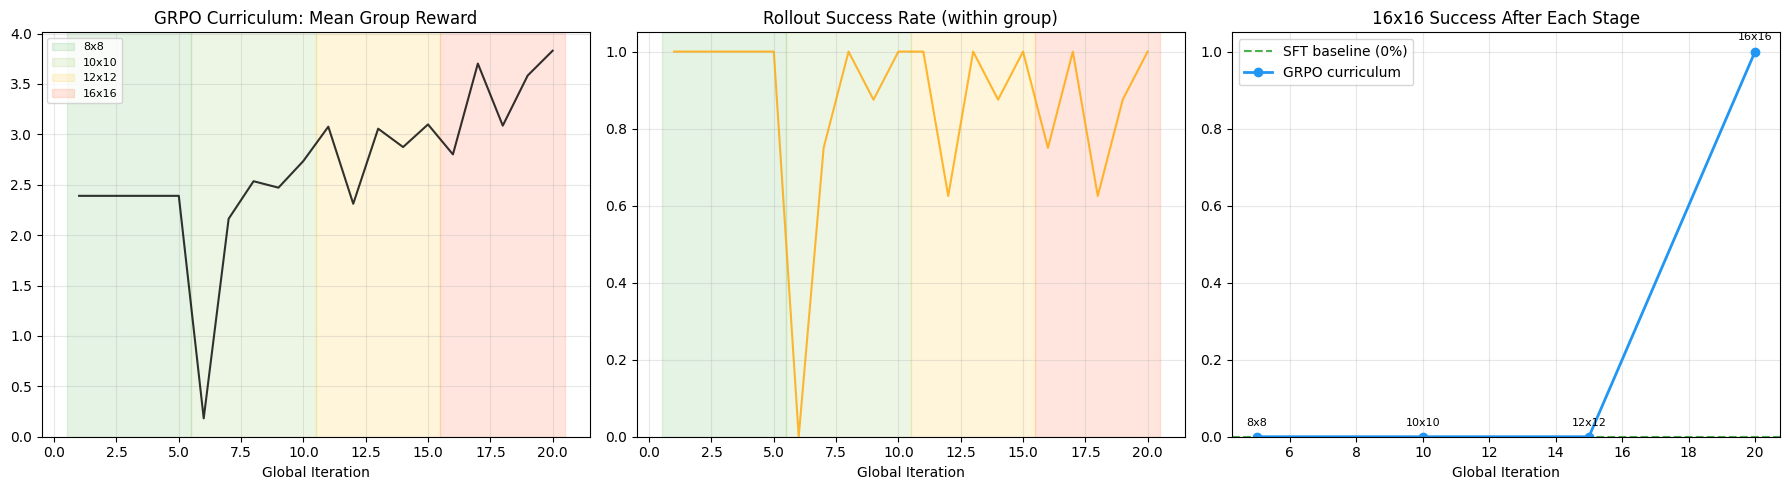

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
stage_colors = ["#4CAF50", "#8BC34A", "#FFC107", "#FF5722"]
stage_names = [env_label(s["env"]) for s in STAGES]

ax = axes[0]
for i in range(len(STAGES)):
    ax.axvspan(stage_boundaries[i] + 0.5, stage_boundaries[i + 1] + 0.5,
               alpha=0.15, color=stage_colors[i], label=stage_names[i])
ax.plot(train_history["iteration"], train_history["mean_reward"], alpha=0.8, color="black")
ax.set_title("GRPO Curriculum: Mean Group Reward")
ax.set_xlabel("Global Iteration")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
for i in range(len(STAGES)):
    ax.axvspan(stage_boundaries[i] + 0.5, stage_boundaries[i + 1] + 0.5,
               alpha=0.15, color=stage_colors[i])
ax.plot(train_history["iteration"], train_history["rollout_success"], alpha=0.8, color="orange")
ax.set_title("Rollout Success Rate (within group)")
ax.set_xlabel("Global Iteration")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

ax = axes[2]
stage_iters = [rec["iteration"] for rec in stage_eval_history]
stage_16_sr = [rec["eval_16x16"]["success_rate"] for rec in stage_eval_history]
ax.axhline(sft_16_sr, color="#4CAF50", linestyle="--", label=f"SFT baseline ({sft_16_sr:.0%})")
ax.plot(stage_iters, stage_16_sr, marker="o", color="#2196F3", linewidth=2, label="GRPO curriculum")
for i, (it, sr) in enumerate(zip(stage_iters, stage_16_sr)):
    ax.annotate(stage_names[i], (it, sr), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_title("16x16 Success After Each Stage")
ax.set_xlabel("Global Iteration")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)


plt.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "grpo_cur_learning_curves.png", dpi=150)
plt.show()

In [ ]:
model.save_pretrained(str(OUTPUT_DIR / "checkpoint"))

results = {
    "method": "GRPO_curriculum",
    "config": {
        "sft_checkpoint": str(SFT_CHECKPOINT),
        "stages": STAGES,
        "k_group": K_GROUP,
        "n_iterations": N_ITERATIONS,
        "lr": LR,
        "beta_kl": BETA_KL,
        "step_penalty": STEP_PENALTY,
        "distance_reward_scale": DISTANCE_REWARD_SCALE,
        "eval_max_steps": EVAL_MAX_STEPS,
    },
    "train_history": train_history,
    "stage_eval_history": stage_eval_history,
    "eval_history": eval_history,
    "eval": {k: v for k, v in grpo_eval.items()},
    "sft_eval_baseline": sft_eval,
    "stage_boundaries": stage_boundaries,
}
with open(OUTPUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Checkpoint: {OUTPUT_DIR / 'checkpoint'}")
print(f"Results:    {OUTPUT_DIR / 'results.json'}")
print(f"Plot:       {OUTPUT_DIR / 'grpo_curriculum_learning_curves.png'}")

Checkpoint: /kaggle/working/grpo_curriculum/checkpoint
Results:    /kaggle/working/grpo_curriculum/results.json
Plot:       /kaggle/working/grpo_curriculum/grpo_curriculum_learning_curves.png


In [ ]:
import os, zipfile, shutil

WORKING = "/kaggle/working/grpo_curriculum"
ARCHIVE = "/kaggle/working/grpo-curriculum-res.zip"

TO_PACK = [
    "checkpoint/config.json",
    "checkpoint/model.safetensors",
    "results.json",
    "grpo_curriculum_learning_curves.png",
]

README = """Stage 2 (GRPO) bundle
Required: checkpoints/sft/config.json + model.safetensors
Compare:   results.json

Load in Stage 2:
  model, tok, proc = load_model_from_checkpoint("/kaggle/input/.../checkpoints/sft")
"""

with zipfile.ZipFile(ARCHIVE, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.writestr("README_STAGE2.txt", README)
    for rel in TO_PACK:
        path = os.path.join(WORKING, rel)
        if os.path.isfile(path):
            zf.write(path, arcname=rel)
            print(f"  + {rel}")
        else:
            print(f"  - skip (missing): {rel}")

size_mb = os.path.getsize(ARCHIVE) / 1024 / 1024
print(f"\nArchive ready: {ARCHIVE} ({size_mb:.0f} MB)")
print("Download: Kaggle → Output → sft_res_final.zip")
print("Then: Save Version (Commit) so Output persists after session ends!")


  + checkpoint/config.json
  + checkpoint/model.safetensors
  + results.json
  + grpo_curriculum_learning_curves.png

Archive ready: /kaggle/working/grpo-curriculum-res.zip (787 MB)
Download: Kaggle → Output → sft_res_final.zip
Then: Save Version (Commit) so Output persists after session ends!


In [ ]:
import json
import shutil
from pathlib import Path

DATASET_NAME = "grpo-curriculum-res"
USERNAME = "gleror"

dataset_dir = Path("/kaggle/working/dataset_for_kaggle")
dataset_dir.mkdir(exist_ok=True)

shutil.copy(
    "/kaggle/working/grpo-curriculum-res.zip",
    dataset_dir / "grpo-curriculum-res.zip"
)

metadata = {
    "title": "grpo-curriculum-res",
    "id": f"{USERNAME}/grpo-curriculum-res",
    "licenses": [{"name": "CC0-1.0"}],
    "isPrivate": True
}

with open(dataset_dir / "dataset-metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Dataset folder prepared:", dataset_dir)

Dataset folder prepared: /kaggle/working/dataset_for_kaggle


In [22]:
!kaggle datasets create \
    -p /kaggle/working/dataset_for_kaggle \
    --dir-mode zip

Starting upload for file grpo-curriculum-res.zip
100%|█████████████████████████████████████████| 787M/787M [00:07<00:00, 117MB/s]
Upload successful: grpo-curriculum-res.zip (787MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/gleror/grpo-curriculum-res
